**CHOCOLATE SALES DATASET 2023-2024**  
This dataset contains synthetic retail transaction data from Kaggle for chocolate sales across multiple stores, customers, and products during the years **2023–2024**. It will be used to do sales analytics, customer behavior analysis and retail performance evaluation

**Importing Required Libraries**

In [3]:
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb


**1.0 Data Loading and Initial Inspection**

**Looking for the files in the Zip folder**


In [4]:
with zipfile.ZipFile("../datasets/chocolate-sales-2023-2024.zip", "r") as z:
    for filename in z.namelist():
        print(filename)

calendar.csv
customers.csv
products.csv
sales.csv
stores.csv


**Making Dataframes for each csv file for easy analysis**

In [5]:
dataframes = {}
with zipfile.ZipFile("../datasets/chocolate-sales-2023-2024.zip", "r") as z:
    for csv_name in z.namelist():
        with z.open(csv_name, "r") as f:
            dataframes[csv_name] = pd.read_csv(f)

dataframes.keys()

dict_keys(['calendar.csv', 'customers.csv', 'products.csv', 'sales.csv', 'stores.csv'])

Inspecting the calendar Dataframe

In [6]:
print(dataframes["calendar.csv"].info())
print(dataframes["calendar.csv"].head())
len(dataframes["calendar.csv"])

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         731 non-null    str  
 1   year         731 non-null    int64
 2   month        731 non-null    int64
 3   day          731 non-null    int64
 4   week         731 non-null    int64
 5   day_of_week  731 non-null    int64
dtypes: int64(5), str(1)
memory usage: 34.4 KB
None
         date  year  month  day  week  day_of_week
0  2023-01-01  2023      1    1    52            6
1  2023-01-02  2023      1    2     1            0
2  2023-01-03  2023      1    3     1            1
3  2023-01-04  2023      1    4     1            2
4  2023-01-05  2023      1    5     1            3


731

The calendar.csv dataframe has one problem, the date column has a string data type instead of date

Inspecting the customers Dataframe

In [7]:
print(dataframes["customers.csv"].info())
print(dataframes["customers.csv"].head())
len(dataframes["customers.csv"])

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     50000 non-null  str  
 1   age             50000 non-null  int64
 2   gender          50000 non-null  str  
 3   loyalty_member  50000 non-null  int64
 4   join_date       50000 non-null  str  
dtypes: int64(2), str(3)
memory usage: 1.9 MB
None
  customer_id  age  gender  loyalty_member   join_date
0     C000001   40    Male               1  2025-05-21
1     C000002   47    Male               0  2021-12-26
2     C000003   58  Female               1  2022-09-13
3     C000004   25  Female               0  2025-02-27
4     C000005   43    Male               0  2023-08-31


50000

The join_date and loyalty_member columns have incorrect data types. They need to have date and boolean data types respectively

Inspecting the products Dataframe

In [8]:
print(dataframes["products.csv"].info())
print(dataframes["products.csv"].head())
len(dataframes["products.csv"])

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     200 non-null    str  
 1   product_name   200 non-null    str  
 2   brand          200 non-null    str  
 3   category       200 non-null    str  
 4   cocoa_percent  200 non-null    int64
 5   weight_g       200 non-null    int64
dtypes: int64(2), str(4)
memory usage: 9.5 KB
None
  product_id           product_name    brand category  cocoa_percent  weight_g
0      P0001    White Chocolate 80%     Mars  Truffle             80       120
1      P0002     Dark Chocolate 70%  Cadbury  Praline             70       100
2      P0003  Truffle Chocolate 70%  Hershey  Praline             70       120
3      P0004     Milk Chocolate 50%     Mars  Praline             50        80
4      P0005    White Chocolate 70%  Ferrero    White             70        50


200

The products.csv dataframe has no problems

Inspecting the sales Dataframe

In [9]:
print(dataframes["sales.csv"].info())
print(dataframes["sales.csv"].head())
len(dataframes["sales.csv"])

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  str    
 1   order_date   1000000 non-null  str    
 2   product_id   1000000 non-null  str    
 3   store_id     1000000 non-null  str    
 4   customer_id  1000000 non-null  str    
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), str(5)
memory usage: 83.9 MB
None
      order_id  order_date product_id store_id customer_id  quantity  \
0  0RD00000001  2023-01-07      P0080     S093     C040749         5   
1  0RD00000002  2023-10-22      P0173     S065     C020161         3   
2  0RD00000003  2023-05-07      P0115     S078 

1000000

The oder_date is has wrong data type

Inspecting the stores Dataframe

In [10]:
print(dataframes["stores.csv"].info())
print(dataframes["stores.csv"].head())
len(dataframes["stores.csv"])

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   store_id    100 non-null    str  
 1   store_name  100 non-null    str  
 2   city        100 non-null    str  
 3   country     100 non-null    str  
 4   store_type  100 non-null    str  
dtypes: str(5)
memory usage: 4.0 KB
None
  store_id         store_name       city country store_type
0     S001  Chocolate Store 1   New York  Canada     Retail
1     S002  Chocolate Store 2  Melbourne  Canada       Mall
2     S003  Chocolate Store 3     Berlin  France       Mall
3     S004  Chocolate Store 4      Paris      UK    Airport
4     S005  Chocolate Store 5     Sydney     USA     Online


100

The stores.csv dataframes is good

The data shows that the sales.csv is related to the remaining four dataframes which means the five data frames can be merged into one data frame.

In [11]:
print(dataframes.keys())

dict_keys(['calendar.csv', 'customers.csv', 'products.csv', 'sales.csv', 'stores.csv'])


**Data Cleaning**

Converting the data type of date column for the calendar

In [26]:
dataframes["calendar.csv"]["date"] = pd.to_datetime(dataframes["calendar.csv"]["date"])
dataframes["calendar.csv"].dtypes

date           datetime64[us]
year                    int64
month                   int64
day                     int64
week                    int64
day_of_week             int64
dtype: object

In [29]:
#Converting join_date to datetime data type in customers dataframe
dataframes["customers.csv"]["join_date"] = pd.to_datetime(dataframes["customers.csv"]["join_date"])

#Converting order_date to datetime data type in sales dataframe
dataframes["sales.csv"]["order_date"] = pd.to_datetime(dataframes["sales.csv"]["order_date"])

**EXPLORATORY DATA ANALYSIS**

Exploring the sales dataframe

In [42]:
sales_df.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [43]:
#Renaming it for easy reference
sales_df = dataframes["sales.csv"]
sales_df.describe()

,order_date,quantity,unit_price,discount,revenue,cost,profit
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023-12-31 19:03:34.991999,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000
50%,2024-01-01 00:00:00,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000
std,NaN,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760


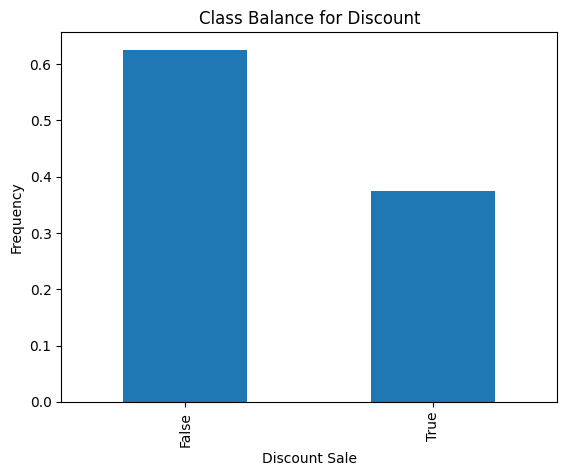

In [55]:
#Converting the discount column into a boolean
discount_sale = sales_df["discount"] > 0

#Plotting a bar chart to see the balance between the quantity of sales made on discount and sales made without discount
discount_sale.value_counts(normalize=True).plot(kind="bar")
plt.title("Class Balance for Discount")
plt.ylabel("Frequency")
plt.xlabel("Discount Sale");

It has been discovered that over 60% sale transactions were made without discount and arount 40% of the total number of sales were made with some discount. Let's now see which of the two scenarios generated more cash

In [59]:
#Total discounts given
float(round(sales_df["discount"].sum(), 2))

56247.85

In [80]:
#Total revenue made from the each class sales
sales_df["discount"] = discount_sale

total_revenue = (sales_df.groupby(sales_df["discount"])["revenue"].sum())/sales_df["revenue"].sum()
total_revenue

discount
False    0.662587
True     0.337413
Name: revenue, dtype: float64

In [81]:
#Total cost made from the each class sales
sales_df["discount"] = discount_sale

total_revenue = (sales_df.groupby(sales_df["discount"])["cost"].sum())/sales_df["cost"].sum()
total_revenue

discount
False    0.662512
True     0.337488
Name: cost, dtype: float64

In [82]:
#Total sales made from the each class sales
sales_df["discount"] = discount_sale

total_sales = (sales_df.groupby(sales_df["discount"])["profit"].sum())/sales_df["profit"].sum()
total_sales

discount
False    0.662699
True     0.337301
Name: profit, dtype: float64

From the analysis of the two discount classes above it shows that the discount sales have no visible impact on the sales revenue, costs and profits. I assumed that from the around 30% sales transactions made on sales with discount, the profit percentage would be more than that as I assumed that most transactions on discount sales would have more sales value beacause of the discount. But it has been shown in the analysis about that discount sales are accounting around the same 30% making my assumption wrong.

In [14]:
con = duckdb.connect()

con.register("calendar", dataframes["calendar.csv"])
con.register("customers", dataframes["customers.csv"])
con.register("products", dataframes["products.csv"])
con.register("sales", dataframes["sales.csv"])
con.register("stores", dataframes["stores.csv"])

df = con.execute(
    """
        SELECT *
        FROM sales as s
        JOIN products as p
        ON s.product_id = p.product_id
        JOIN customers as c
        ON s.customer_id = c.customer_id
    """
).df()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        990236 non-null  str    
 1   order_date      990236 non-null  str    
 2   product_id      990236 non-null  str    
 3   store_id        990236 non-null  str    
 4   customer_id     990236 non-null  str    
 5   quantity        990236 non-null  int64  
 6   unit_price      990236 non-null  float64
 7   discount        990236 non-null  float64
 8   revenue         990236 non-null  float64
 9   cost            990236 non-null  float64
 10  profit          990236 non-null  float64
 11  product_id_1    990236 non-null  str    
 12  product_name    990236 non-null  str    
 13  brand           990236 non-null  str    
 14  category        990236 non-null  str    
 15  cocoa_percent   990236 non-null  int64  
 16  weight_g        990236 non-null  int64  
 17  customer_id_1   99023